In [ ]:

#MNIST NN from scratch (numpy And Maths) , (No tensorflow and no keras).


In [2]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 

In [3]:
d1 = pd.read_csv('sample_submission.csv')
d1

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
27995,27996,0
27996,27997,0
27997,27998,0
27998,27999,0


In [4]:
d2 = pd.read_csv('test.csv')
d2

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
d3 = pd.read_csv('train.csv')
d3

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
d3 = np.array(d3)
m, n = d3.shape
np.random.shuffle(d3) # shuffle before splitting into dev and training sets

data_dev = d3[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = d3[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [9]:
Y_train

array([5, 2, 1, ..., 8, 7, 1])

Forward propagation: 

    𝑍[1]=𝑊[1]𝑋+𝑏[1]
    𝐴[1]=𝑔ReLU(𝑍[1]))
    𝑍[2]=𝑊[2]𝐴[1]+𝑏[2]
    𝐴[2]=𝑔softmax(𝑍[2])

Backward propagation:

    𝑑𝑍[2]=𝐴[2]−𝑌
    𝑑𝑊[2]=1𝑚𝑑𝑍[2]𝐴[1]𝑇
    𝑑𝐵[2]=1𝑚Σ𝑑𝑍[2]
    𝑑𝑍[1]=𝑊[2]𝑇𝑑𝑍[2].∗𝑔[1]′(𝑧[1])
    𝑑𝑊[1]=1𝑚𝑑𝑍[1]𝐴[0]𝑇
    𝑑𝐵[1]=1𝑚Σ𝑑𝑍[1]    

Parameter updates:

    𝑊[2]:=𝑊[2]−𝛼𝑑𝑊[2]
 
    𝑏[2]:=𝑏[2]−𝛼𝑑𝑏[2]
 
    𝑊[1]:=𝑊[1]−𝛼𝑑𝑊[1]
 
    𝑏[1]:=𝑏[1]−𝛼𝑑𝑏[1]

Vars and shapes:

Forward prop:

            𝐴[0]=𝑋
             : 784 x m
            𝑍[1]∼𝐴[1]
             : 10 x m
            𝑊[1]
             : 10 x 784 (as  𝑊[1]𝐴[0]∼𝑍[1]
             )
            𝐵[1]
             : 10 x 1
            𝑍[2]∼𝐴[2]
             : 10 x m
            𝑊[1]
             : 10 x 10 (as  𝑊[2]𝐴[1]∼𝑍[2]
             )
            𝐵[2]
             : 10 x 1
Backprop:

            𝑑𝑍[2]
             : 10 x m (  𝐴[2]
             )
            𝑑𝑊[2]
             : 10 x 10
            𝑑𝐵[2]
             : 10 x 1
            𝑑𝑍[1]
             : 10 x m (  𝐴[1]
             )
            𝑑𝑊[1]
             : 10 x 10
            𝑑𝐵[1]
             : 10 x 1

In [10]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
    
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2


In [11]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [12]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[1 4 7 ... 4 3 3] [5 2 1 ... 8 7 1]
0.07739024390243902
Iteration:  10
[1 1 3 ... 0 7 3] [5 2 1 ... 8 7 1]
0.1314390243902439
Iteration:  20
[1 6 3 ... 0 7 3] [5 2 1 ... 8 7 1]
0.1823170731707317
Iteration:  30
[6 6 3 ... 6 7 3] [5 2 1 ... 8 7 1]
0.2261219512195122
Iteration:  40
[6 6 3 ... 6 7 3] [5 2 1 ... 8 7 1]
0.26309756097560977
Iteration:  50
[6 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.3405609756097561
Iteration:  60
[0 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.39465853658536587
Iteration:  70
[0 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.4282439024390244
Iteration:  80
[0 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.45582926829268294
Iteration:  90
[0 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.48604878048780487
Iteration:  100
[0 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.5170975609756098
Iteration:  110
[3 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.5460487804878049
Iteration:  120
[3 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.572170731707317
Iteration:  130
[3 8 1 ... 6 7 1] [5 2 1 ... 8 7 1]
0.5933658536585366
Iteration:  1

~85% accuracy on training set.

In [13]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Test Examples:

Prediction:  [5]
Label:  5


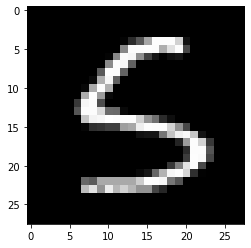

Prediction:  [2]
Label:  2


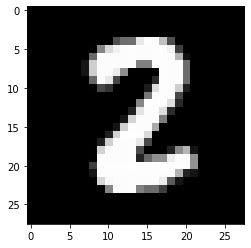

Prediction:  [1]
Label:  1


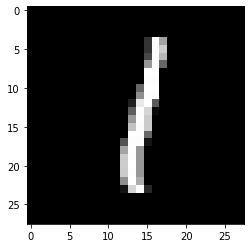

Prediction:  [5]
Label:  4


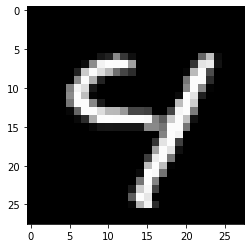

In [14]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)